# ДЗ 5. Depth Anything 3

Строю карты относительной глубины по RGB и кладу их в классификацию STL-10 на одном ResNet18: четыре варианта входа, RGB, Depth-only, RGB-D, Two-Stream, метрики Accuracy и macro-F1

## Конфиг

In [1]:
import os

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

device = "mps" if torch.backends.mps.is_available() else "cpu"
DA3_MODEL_ID = "depth-anything/DA3-SMALL"

DATASET = "STL10"
N_TRAIN = 2500
N_TEST = 500
IMG_SIZE = 96
BATCH = 32
EPOCHS = 15
LR = 1e-4

DATA_ROOT = "./data"

print("device:", device)
print("DA3 model:", DA3_MODEL_ID)


device: mps
DA3 model: depth-anything/DA3-SMALL


In [2]:
# !pip install -q "numpy<2" depth-anything-3

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm


/Users/askar/study/ml_hse_sem2/.venv-hw5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка DA3

In [ ]:
from depth_anything_3.api import DepthAnything3

da3 = DepthAnything3.from_pretrained(DA3_MODEL_ID).to(device).eval()
for p in da3.parameters():
    p.requires_grad_(False)

print(DA3_MODEL_ID)


[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70
[INFO ] using MLP layer as FFN
DA3 загружена: depth-anything/DA3-SMALL


In [4]:
@torch.no_grad()
def da3_depth(pil_img, out_size=IMG_SIZE):
    pred = da3.inference(image=[np.array(pil_img)])
    depth = torch.as_tensor(np.asarray(pred.depth[0]), dtype=torch.float32)
    depth = F.interpolate(depth[None, None], size=(out_size, out_size),
                          mode="bilinear", align_corners=False)[0, 0]
    d_min, d_max = depth.min(), depth.max()
    depth = (depth - d_min) / (d_max - d_min + 1e-6)
    return depth.cpu().numpy().astype(np.float32)


## STL-10

96×96, 10 классов выборка 2500 train / 500 test.

In [5]:
set_seed()

stl_train = datasets.STL10(DATA_ROOT, split="train", download=True)
stl_test = datasets.STL10(DATA_ROOT, split="test", download=True)

CLASSES = stl_train.classes

def subset_indices(ds, n):
    idx = np.arange(len(ds))
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    return idx[:n]

train_idx = subset_indices(stl_train, N_TRAIN)
test_idx = subset_indices(stl_test, N_TEST)

print("train:", len(train_idx), "test:", len(test_idx), "классов:", len(CLASSES))
print(CLASSES)


train: 2500 test: 500 классов: 10
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## Генерация карт глубины

Прогон DA3 по всем картинкам с нормализацией глубины

In [6]:
def build_depths(ds, indices):
    depths = np.zeros((len(indices), IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for i, j in enumerate(tqdm(indices, desc="DA3 depth")):
        img, _ = ds[int(j)]
        depths[i] = da3_depth(img)
    return depths

train_depth = build_depths(stl_train, train_idx)
test_depth = build_depths(stl_test, test_idx)

train_labels = np.array([stl_train[int(j)][1] for j in train_idx])
test_labels = np.array([stl_test[int(j)][1] for j in test_idx])

print("depth:", train_depth.shape, test_depth.shape)


DA3 depth:   0%|          | 0/2500 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.035539865493774414 seconds. Shape:  torch.Size([1, 3, 504, 504])


DA3 depth:   0%|          | 1/2500 [00:00<38:38,  1.08it/s]

[INFO ] Model Forward Pass Done. Time: 0.8461048603057861 seconds
[INFO ] Conversion to Prediction Done. Time: 0.026348114013671875 seconds
[INFO ] Processed Images Done taking 0.007700920104980469 seconds. Shape:  torch.Size([1, 3, 504, 504])


DA3 depth:   0%|          | 2/2500 [00:01<21:25,  1.94it/s]

...

DA3 depth: 100%|█████████▉| 499/500 [01:47<00:00,  4.02it/s]

[INFO ] Model Forward Pass Done. Time: 0.19274592399597168 seconds
[INFO ] Conversion to Prediction Done. Time: 0.03336310386657715 seconds
[INFO ] Processed Images Done taking 0.009710073471069336 seconds. Shape:  torch.Size([1, 3, 504, 504])


DA3 depth: 100%|██████████| 500/500 [01:47<00:00,  4.65it/s]

[INFO ] Model Forward Pass Done. Time: 0.17652106285095215 seconds
[INFO ] Conversion to Prediction Done. Time: 0.040596961975097656 seconds


depth: (2500, 96, 96) (500, 96, 96)


## Карты глубины RGB в depth

Проверяю, что объект отделяется от фона и виден градиент перспективы.

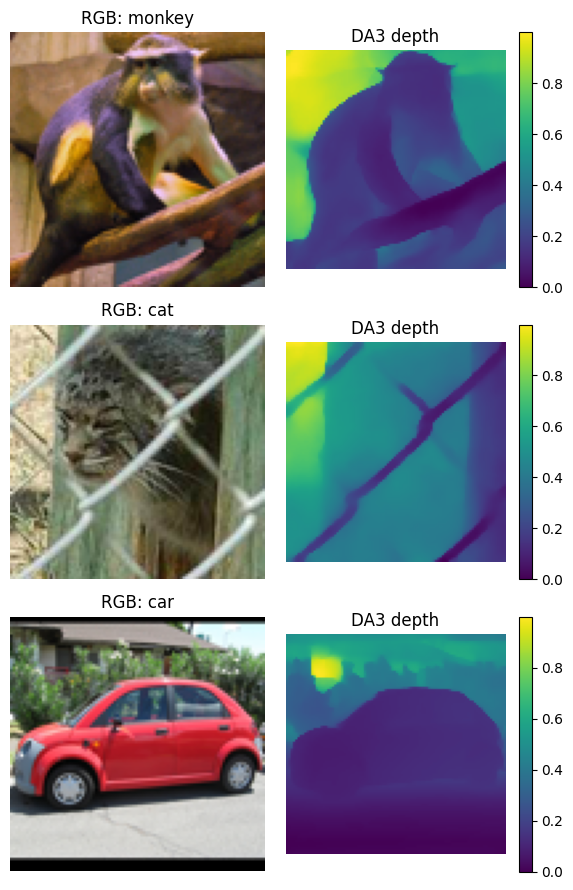

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
rng = np.random.default_rng(0)
show = rng.choice(len(train_idx), 3, replace=False)
for row, k in enumerate(show):
    img, lab = stl_train[int(train_idx[k])]
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"RGB: {CLASSES[lab]}")
    im = axes[row, 1].imshow(train_depth[k])
    axes[row, 1].set_title("DA3 depth")
    fig.colorbar(im, ax=axes[row, 1])
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()


Получилось неплохо, но кота не определило

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

rgb_norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

class RGBDDataset(Dataset):
    def __init__(self, base_ds, indices, depths, labels, train=False):
        self.base_ds = base_ds
        self.indices = indices
        self.depths = depths
        self.labels = labels
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.base_ds[int(self.indices[i])]
        if self.train and random.random() < 0.5:
            img = transforms.functional.hflip(img)
            depth = np.ascontiguousarray(self.depths[i][:, ::-1])
        else:
            depth = self.depths[i]
        rgb = rgb_norm(transforms.functional.to_tensor(img))
        depth = torch.from_numpy(depth)[None]
        depth = (depth - 0.5) / 0.25
        rgbd = torch.cat([rgb, depth], dim=0)
        return rgb, depth, rgbd, int(self.labels[i])

train_ds = RGBDDataset(stl_train, train_idx, train_depth, train_labels, train=True)
test_ds = RGBDDataset(stl_test, test_idx, test_depth, test_labels, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)


## Модели

ResNet18 с весами ImageNet. Для Depth-only и RGB-D пересобираю conv1 под нужное число каналов, 4-й канал инициализирую средним по RGB-весам.

In [9]:
def adapt_conv1(model, in_ch):
    old = model.conv1.weight.data
    new = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
    if in_ch == 3:
        new.weight.data = old.clone()
    elif in_ch == 1:
        new.weight.data = old.mean(dim=1, keepdim=True)
    elif in_ch == 4:
        new.weight.data[:, :3] = old.clone()
        new.weight.data[:, 3:4] = old.mean(dim=1, keepdim=True)
    model.conv1 = new
    return model

def make_resnet(in_ch, n_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    adapt_conv1(m, in_ch)
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m

class TwoStream(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        rgb = make_resnet(3, n_classes)
        depth = make_resnet(1, n_classes)
        self.rgb_feat = nn.Sequential(*list(rgb.children())[:-1])
        self.depth_feat = nn.Sequential(*list(depth.children())[:-1])
        self.head = nn.Linear(512 * 2, n_classes)

    def forward(self, rgb, depth):
        fr = self.rgb_feat(rgb).flatten(1)
        fd = self.depth_feat(depth).flatten(1)
        return self.head(torch.cat([fr, fd], dim=1))


## Обучение, оценка

In [10]:
def select_inputs(regime, rgb, depth, rgbd):
    if regime == "RGB":
        return (rgb,)
    if regime == "Depth-only":
        return (depth,)
    if regime == "RGB-D":
        return (rgbd,)
    return (rgb, depth)

def evaluate(model, regime):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for rgb, depth, rgbd, y in test_loader:
            rgb, depth, rgbd = rgb.to(device), depth.to(device), rgbd.to(device)
            ins = [t for t in select_inputs(regime, rgb, depth, rgbd)]
            logits = model(*ins)
            preds.append(logits.argmax(1).cpu().numpy())
            gts.append(y.numpy())
    preds = np.concatenate(preds)
    gts = np.concatenate(gts)
    return accuracy_score(gts, preds), f1_score(gts, preds, average="macro")

def train_regime(regime):
    set_seed()
    if regime == "Two-Stream":
        model = TwoStream(len(CLASSES)).to(device)
    else:
        in_ch = {"RGB": 3, "Depth-only": 1, "RGB-D": 4}[regime]
        model = make_resnet(in_ch, len(CLASSES)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()
    history = {"loss": [], "acc": [], "f1": []}
    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for rgb, depth, rgbd, y in train_loader:
            rgb, depth, rgbd, y = rgb.to(device), depth.to(device), rgbd.to(device), y.to(device)
            ins = select_inputs(regime, rgb, depth, rgbd)
            opt.zero_grad()
            loss = crit(model(*ins), y)
            loss.backward()
            opt.step()
            running += loss.item() * y.size(0)
        acc, f1 = evaluate(model, regime)
        history["loss"].append(running / len(train_ds))
        history["acc"].append(acc)
        history["f1"].append(f1)
        print(f"[{regime}] epoch {epoch+1:2d}  loss {history['loss'][-1]:.3f}  acc {acc:.3f}  f1 {f1:.3f}")
    return model, history

REGIMES = ["RGB", "Depth-only", "RGB-D", "Two-Stream"]
results = {}
for r in REGIMES:
    _, results[r] = train_regime(r)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/askar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.59MB/s]


[RGB] epoch  1  loss 0.945  acc 0.860  f1 0.862
[RGB] epoch  2  loss 0.289  acc 0.864  f1 0.865
[RGB] epoch  3  loss 0.142  acc 0.880  f1 0.881
[RGB] epoch  4  loss 0.076  acc 0.870  f1 0.870
[RGB] epoch  5  loss 0.063  acc 0.874  f1 0.874
[RGB] epoch  6  loss 0.054  acc 0.872  f1 0.875
[RGB] epoch  7  loss 0.036  acc 0.878  f1 0.881
[RGB] epoch  8  loss 0.027  acc 0.874  f1 0.875
[RGB] epoch  9  loss 0.034  acc 0.866  f1 0.867
[RGB] epoch 10  loss 0.051  acc 0.842  f1 0.843
[RGB] epoch 11  loss 0.069  acc 0.840  f1 0.842
[RGB] epoch 12  loss 0.029  acc 0.850  f1 0.850
[RGB] epoch 13  loss 0.043  acc 0.870  f1 0.872
[RGB] epoch 14  loss 0.063  acc 0.856  f1 0.858
[RGB] epoch 15  loss 0.060  acc 0.856  f1 0.858
[Depth-only] epoch  1  loss 1.384  acc 0.658  f1 0.665
[Depth-only] epoch  2  loss 0.672  acc 0.664  f1 0.667
[Depth-only] epoch  3  loss 0.412  acc 0.644  f1 0.649
[Depth-only] epoch  4  loss 0.302  acc 0.676  f1 0.684
[Depth-only] epoch  5  loss 0.165  acc 0.672  f1 0.683
[Dept

## Сравнение

In [11]:
import pandas as pd

table = pd.DataFrame({
    "Accuracy": [max(results[r]["acc"]) for r in REGIMES],
    "macro-F1": [results[r]["f1"][int(np.argmax(results[r]["acc"]))] for r in REGIMES],
}, index=REGIMES).round(4)
table


,Accuracy,macro-F1
RGB,0.880,0.8810
Depth-only,0.698,0.7022
RGB-D,0.872,0.8726
Two-Stream,0.888,0.8906


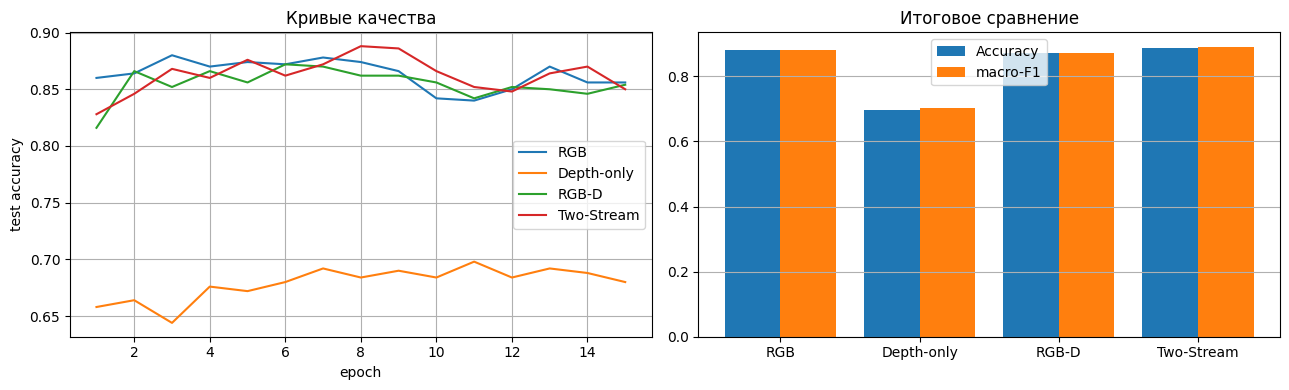

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r in REGIMES:
    ax[0].plot(range(1, EPOCHS + 1), results[r]["acc"], label=r)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("test accuracy")
ax[0].set_title("Кривые качества")
ax[0].legend()
ax[0].grid(True)

x = np.arange(len(REGIMES))
ax[1].bar(x - 0.2, table["Accuracy"], 0.4, label="Accuracy")
ax[1].bar(x + 0.2, table["macro-F1"], 0.4, label="macro-F1")
ax[1].set_xticks(x)
ax[1].set_xticklabels(REGIMES)
ax[1].set_title("Итоговое сравнение")
ax[1].legend()
ax[1].grid(True, axis="y")
plt.tight_layout()
plt.show()


## Устойчивость RGB и RGB-D с искажениями

Затемняю, добавляю шум, прогоняю DA3 на искаженной картинке и сравниваю RGB с RGB-D.

In [13]:
def degrade(pil_img):
    arr = np.asarray(pil_img).astype(np.float32) / 255.0
    arr = arr * 0.3
    arr = arr + np.random.default_rng(0).normal(0, 0.08, arr.shape)
    arr = np.clip(arr, 0, 1)
    return transforms.functional.to_pil_image(torch.from_numpy(arr).permute(2, 0, 1))

def build_degraded_depths(ds, indices):
    depths = np.zeros((len(indices), IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for i, j in enumerate(tqdm(indices, desc="DA3 degraded")):
        img, _ = ds[int(j)]
        depths[i] = da3_depth(degrade(img))
    return depths

deg_test_depth = build_degraded_depths(stl_test, test_idx)


DA3 degraded:   0%|          | 0/500 [00:00<?, ?it/s]

[INFO ] Processed Images Done taking 0.006140947341918945 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.16592788696289062 seconds


DA3 degraded:   0%|          | 1/500 [00:00<01:50,  4.52it/s]

[INFO ] Conversion to Prediction Done. Time: 0.04331326484680176 seconds
[INFO ] Processed Images Done taking 0.0035161972045898438 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.13146185874938965 seconds


DA3 degraded:   0%|          | 2/500 [00:00<01:40,  4.93it/s]

...

[INFO ] Model Forward Pass Done. Time: 0.1664261817932129 seconds
[INFO ] Conversion to Prediction Done. Time: 0.04621696472167969 seconds
[INFO ] Processed Images Done taking 0.002516031265258789 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.1296229362487793 seconds


DA3 degraded: 100%|█████████▉| 499/500 [01:35<00:00,  5.23it/s]

[INFO ] Conversion to Prediction Done. Time: 0.04461097717285156 seconds
[INFO ] Processed Images Done taking 0.002988100051879883 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.13277101516723633 seconds
[INFO ] Conversion to Prediction Done. Time: 0.043781280517578125 seconds
[INFO ] Processed Images Done taking 0.004650115966796875 seconds. Shape:  torch.Size([1, 3, 504, 504])


DA3 degraded: 100%|██████████| 500/500 [01:35<00:00,  5.22it/s]

[INFO ] Model Forward Pass Done. Time: 0.1368708610534668 seconds
[INFO ] Conversion to Prediction Done. Time: 0.042402029037475586 seconds


In [14]:
class DegradedTestDataset(Dataset):
    def __init__(self, base_ds, indices, depths, labels):
        self.base_ds, self.indices, self.depths, self.labels = base_ds, indices, depths, labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.base_ds[int(self.indices[i])]
        dimg = degrade(img)
        rgb = rgb_norm(transforms.functional.to_tensor(dimg))
        depth = (torch.from_numpy(self.depths[i])[None] - 0.5) / 0.25
        rgbd = torch.cat([rgb, depth], dim=0)
        return rgb, depth, rgbd, int(self.labels[i])

deg_loader = DataLoader(DegradedTestDataset(stl_test, test_idx, deg_test_depth, test_labels),
                        batch_size=BATCH, shuffle=False)

def eval_loader(model, regime, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for rgb, depth, rgbd, y in loader:
            rgb, depth, rgbd = rgb.to(device), depth.to(device), rgbd.to(device)
            ins = select_inputs(regime, rgb, depth, rgbd)
            preds.append(model(*ins).argmax(1).cpu().numpy())
            gts.append(y.numpy())
    preds, gts = np.concatenate(preds), np.concatenate(gts)
    return accuracy_score(gts, preds), f1_score(gts, preds, average="macro")

rob_rows = {}
for r in ["RGB", "RGB-D"]:
    model, _ = train_regime(r)
    clean = evaluate(model, r)
    deg = eval_loader(model, r, deg_loader)
    rob_rows[r] = {"clean acc": clean[0], "degraded acc": deg[0]}

rob_table = pd.DataFrame(rob_rows).T.round(4)
rob_table["drop"] = (rob_table["clean acc"] - rob_table["degraded acc"]).round(4)
rob_table


[RGB] epoch  1  loss 0.945  acc 0.860  f1 0.862
[RGB] epoch  2  loss 0.289  acc 0.864  f1 0.865
[RGB] epoch  3  loss 0.142  acc 0.880  f1 0.881
[RGB] epoch  4  loss 0.076  acc 0.870  f1 0.870
[RGB] epoch  5  loss 0.063  acc 0.874  f1 0.874
[RGB] epoch  6  loss 0.054  acc 0.872  f1 0.875
[RGB] epoch  7  loss 0.036  acc 0.878  f1 0.881
[RGB] epoch  8  loss 0.027  acc 0.874  f1 0.875
[RGB] epoch  9  loss 0.034  acc 0.866  f1 0.867
[RGB] epoch 10  loss 0.051  acc 0.842  f1 0.843
[RGB] epoch 11  loss 0.069  acc 0.840  f1 0.842
[RGB] epoch 12  loss 0.029  acc 0.850  f1 0.850
[RGB] epoch 13  loss 0.043  acc 0.870  f1 0.872
[RGB] epoch 14  loss 0.063  acc 0.856  f1 0.858
[RGB] epoch 15  loss 0.060  acc 0.856  f1 0.858
[RGB-D] epoch  1  loss 0.925  acc 0.816  f1 0.817
[RGB-D] epoch  2  loss 0.291  acc 0.866  f1 0.869
[RGB-D] epoch  3  loss 0.146  acc 0.852  f1 0.854
[RGB-D] epoch  4  loss 0.091  acc 0.866  f1 0.866
[RGB-D] epoch  5  loss 0.060  acc 0.856  f1 0.856
[RGB-D] epoch  6  loss 0.037  

,clean acc,degraded acc,drop
RGB,0.856,0.170,0.686
RGB-D,0.854,0.202,0.652


## Дистилляция DA3, teacher - student

DA3 размечает RGB в depth, маленький encoder-decoder учится повторять глубину. Качество student меряю против teacher

In [15]:
class TinyDepthNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
        self.enc1 = block(3, 32)
        self.enc2 = block(32, 64)
        self.enc3 = block(64, 128)
        self.dec2 = block(128, 64)
        self.dec1 = block(64, 32)
        self.out = nn.Conv2d(32, 1, 1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        d2 = self.dec2(self.up(e3))
        d1 = self.dec1(self.up(d2))
        return torch.sigmoid(self.out(d1))

def gradient_loss(pred, target):
    pdx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    tdx = target[:, :, :, 1:] - target[:, :, :, :-1]
    pdy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    tdy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return (pdx - tdx).abs().mean() + (pdy - tdy).abs().mean()


In [16]:
class DistillDataset(Dataset):
    def __init__(self, base_ds, indices, depths):
        self.base_ds, self.indices, self.depths = base_ds, indices, depths

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.base_ds[int(self.indices[i])]
        rgb = rgb_norm(transforms.functional.to_tensor(img))
        return rgb, torch.from_numpy(self.depths[i])[None]

distill_train = DataLoader(DistillDataset(stl_train, train_idx, train_depth), batch_size=BATCH, shuffle=True)
distill_test = DataLoader(DistillDataset(stl_test, test_idx, test_depth), batch_size=BATCH, shuffle=False)

set_seed()
student = TinyDepthNet().to(device)
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
DISTILL_EPOCHS = 12
for epoch in range(DISTILL_EPOCHS):
    student.train()
    total = 0.0
    for rgb, target in distill_train:
        rgb, target = rgb.to(device), target.to(device)
        pred = student(rgb)
        loss = F.l1_loss(pred, target) + 0.5 * gradient_loss(pred, target)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * rgb.size(0)
    print(f"[distill] epoch {epoch+1:2d}  loss {total/len(train_idx):.4f}")


[distill] epoch  1  loss 0.2295
[distill] epoch  2  loss 0.2128
[distill] epoch  3  loss 0.2076
[distill] epoch  4  loss 0.2044
[distill] epoch  5  loss 0.2035
[distill] epoch  6  loss 0.2006
[distill] epoch  7  loss 0.1998
[distill] epoch  8  loss 0.1986
[distill] epoch  9  loss 0.1974
[distill] epoch 10  loss 0.1955
[distill] epoch 11  loss 0.1941
[distill] epoch 12  loss 0.1957


In [17]:
def depth_metrics(student, loader):
    student.eval()
    absrel, rmse, d1, ps, ts = [], [], [], [], []
    with torch.no_grad():
        for rgb, target in loader:
            rgb, target = rgb.to(device), target.to(device)
            pred = student(rgb)
            p = pred.clamp(1e-3, 1).flatten(1)
            t = target.clamp(1e-3, 1).flatten(1)
            absrel.append(((p - t).abs() / t).mean(1).cpu().numpy())
            rmse.append(torch.sqrt(((p - t) ** 2).mean(1)).cpu().numpy())
            ratio = torch.maximum(p / t, t / p)
            d1.append((ratio < 1.25).float().mean(1).cpu().numpy())
            ps.append(p.cpu().numpy())
            ts.append(t.cpu().numpy())
    ps = np.concatenate(ps).ravel()
    ts = np.concatenate(ts).ravel()
    pearson = np.corrcoef(ps, ts)[0, 1]
    return {
        "AbsRel": float(np.concatenate(absrel).mean()),
        "RMSE": float(np.concatenate(rmse).mean()),
        "delta<1.25": float(np.concatenate(d1).mean()),
        "Pearson r": float(pearson),
    }

distill_metrics = pd.Series(depth_metrics(student, distill_test)).round(4)
distill_metrics


AbsRel        1.6116
RMSE          0.2189
delta<1.25    0.2900
Pearson r     0.6207
dtype: float64

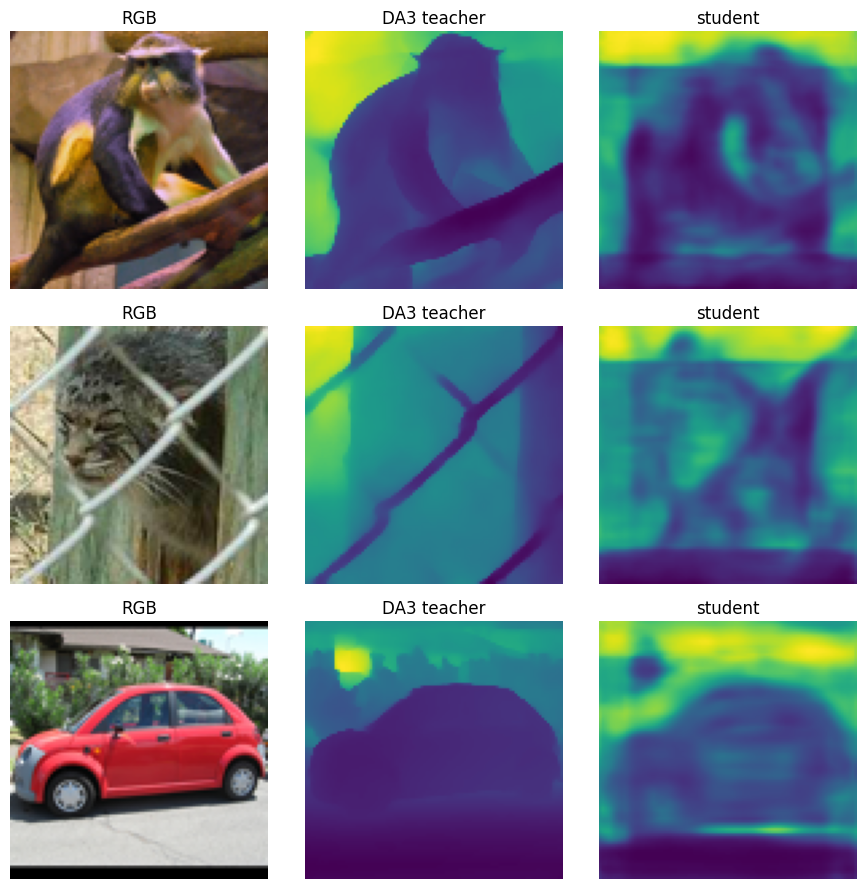

In [18]:
student.eval()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
with torch.no_grad():
    for row, k in enumerate(show):
        img, lab = stl_train[int(train_idx[k])]
        rgb = rgb_norm(transforms.functional.to_tensor(img))[None].to(device)
        pred = student(rgb)[0, 0].cpu().numpy()
        axes[row, 0].imshow(img); axes[row, 0].set_title("RGB")
        axes[row, 1].imshow(train_depth[k]); axes[row, 1].set_title("DA3 teacher")
        axes[row, 2].imshow(pred); axes[row, 2].set_title("student")
        for ax in axes[row]:
            ax.axis("off")
plt.tight_layout()
plt.show()


## Выводы

| режим | acc | macro-F1 |
|---|---|---|
| RGB | 0.880 | 0.881 |
| Depth-only | 0.698 | 0.702 |
| RGB-D | 0.872 | 0.873 |
| Two-Stream | 0.888 | 0.891 |

Глубина из DA3 для STL-10 дает немного: возможно так как выведена из RGB. Под искажениями обе модели сильно деградируют, глубина портится вместе с RGB. 
Teacher повторяет контуры, student нет